# GRU (Gated Recurrent Unit) — Sequence Modeling Types on Hourly Energy Data

This notebook builds **five classic RNN input/output typologies** — one-to-one,
many-to-one, one-to-many, many-to-many (synced), and many-to-many (encoder-decoder /
seq2seq) — all using **`tf.keras.layers.GRU`** as the recurrent
cell, via the Keras **Sequential API**. Every architecture is trained on the same
hourly Spanish electricity dataset (load, generation mix, price), so the only thing
that changes between sections is the *shape* of the supervised learning problem, not
the data or the cell type.

Each model trains for **100 epochs** and is drawn as a layer diagram before training
(`show_model_diagram`). Every `Sequential([...])` block also includes a **commented-out
second GRU layer** with a one-line note on what to flip — uncomment it
to go from a single-layer to a stacked (deep) recurrent network for that architecture.

## 1. The GRU Cell


$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t]) \quad \text{(update gate)}$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t]) \quad \text{(reset gate)}$$
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t]) \quad \text{(candidate activation)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t \quad \text{(hidden state update)}$$

GRU merges the cell state and hidden state into a single $h_t$ and uses only two
gates: a **reset gate** $r_t$ (how much of the past to ignore when computing the
candidate) and an **update gate** $z_t$ (how much of the past to keep vs. replace
with the candidate). Fewer gates than LSTM means fewer parameters and often faster
training, while still solving the vanishing-gradient problem via the same additive,
gated-update mechanism.


### What you'll build

1. Load & clean the hourly energy dataset (with an offline synthetic fallback)
2. Chronological train/val/test split + scaling
3. Windowing utilities shared by all five architectures
4. **One-to-one** — single step in, single step out
5. **Many-to-one** — a window of history, one prediction
6. **One-to-many** — one snapshot, a generated forecast sequence
7. **Many-to-many (synced)** — a window in, one aligned prediction per step
8. **Many-to-many (seq2seq)** — a window of history, a differently-sized future window
9. Side-by-side comparison of parameter counts and validation performance


## 1b. Setup and Imports

Model architecture diagrams later in this notebook (`show_model_diagram`) need the `pydot` package and the Graphviz `dot` executable. If they're missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
# Debian/Ubuntu:
sudo apt-get install graphviz
# macOS:
brew install graphviz
```

In [ ]:
# Loretta Cruz
# Bioinformatics
# Assignment/Quiz-GRU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100


## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

The dataset contains ~4 years (2015–2018) of hourly Spanish electricity data in
`energy_dataset.csv`: total load, generation by source (solar, wind, gas, nuclear, ...),
day-ahead price forecasts, and actual settled prices.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated):
   ```bash
   pip install kagglehub
   ```

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so every
cell in this notebook still runs end-to-end without the real file. Swap in the real
CSV at any time — no other code needs to change, since every downstream cell only
depends on `FEATURE_COLS` / `TARGET_COL` existing in `df`.


In [2]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) "
              "so the rest of the notebook still runs end-to-end.")
        print("[info] See section 2 above for instructions on installing the real dataset.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

[info] Could not load the real Kaggle dataset (ModuleNotFoundError: No module named 'kagglehub').
[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) so the rest of the notebook still runs end-to-end.
[info] See section 2 above for instructions on installing the real dataset.
(3000, 5)


,total load actual,generation solar,generation wind onshore,generation fossil gas,price actual
time,,,,,
2018-01-01 00:00:00,26121.886832,187.353405,4635.070036,4584.255276,44.270897
2018-01-01 01:00:00,26619.500704,103.153828,4562.198944,4264.948320,47.950673
2018-01-01 02:00:00,28300.616808,294.919121,5206.577410,4379.785560,43.654361
2018-01-01 03:00:00,29205.307501,0.000000,5145.621944,4112.532146,45.508473
2018-01-01 04:00:00,28684.560185,0.000000,3082.747523,5431.236878,56.400750


In [3]:
# Keep only the columns this notebook uses, make the index a clean hourly
# DatetimeIndex, and fill any gaps (the real Kaggle file has a handful of
# missing hours/values).
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 3000   Range: 2018-01-01 00:00:00 -> 2018-05-05 23:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,3000.0,26012.466411,2975.575803,20148.011389,23364.934962,25988.117226,28674.494125,31850.097397
generation solar,3000.0,1141.780903,1337.615992,0.000000,0.000000,205.759112,2478.679081,3926.794159
generation wind onshore,3000.0,4497.836590,1415.426687,702.029260,3317.783483,4467.156718,5702.256882,8138.970495
generation fossil gas,3000.0,4300.230074,654.780603,2207.562638,3849.895831,4305.334437,4777.894254,6544.394789
price actual,3000.0,43.732220,8.036112,21.911996,37.781904,43.278355,49.695438,66.798140



## 3. Feature Engineering & Scaling

This is time-series data, so the train/validation/test split must be **chronological**
(no shuffling) — otherwise the model would be validated on data that "leaks" future
information it was trained on. We fit the scaler on the training slice only, then
apply it to validation/test, which mirrors how you'd deploy this in production
(you never get to peek at the future to normalize the past).


In [4]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=2100  val=450  test=450  n_features=5



## 4. Windowing Utilities

Each RNN *type* below needs its (X, y) pairs built differently from the same
underlying hourly series. These five helpers turn a scaled dataframe into the
right tensor shapes for Keras:

| Type | X shape | y shape | Meaning |
|---|---|---|---|
| One-to-one | `(n, 1, features)` | `(n, 1)` | single timestep in -> single value out |
| Many-to-one | `(n, window, features)` | `(n, 1)` | a window of history -> next single value |
| One-to-many | `(n, 1, features)` | `(n, out_len, 1)` | a single timestep -> a forecast sequence |
| Many-to-many (synced) | `(n, window, features)` | `(n, window, 1)` | a window -> one prediction per input step |
| Many-to-many (seq2seq) | `(n, in_window, features)` | `(n, out_horizon, 1)` | a window of history -> a future window |

All five draw from `TARGET_COL` (`price actual`) as the value being predicted/generated.


In [5]:
def make_one_to_one(data: pd.DataFrame):
    """Single timestep in -> the very next single timestep's target out."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - 1):
        X.append(values[t : t + 1])          # (1, features)
        y.append([target[t + 1]])             # (1,)
    return np.array(X), np.array(y)


def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


def make_one_to_many(data: pd.DataFrame, out_len: int = 6):
    """A single timestep -> the next `out_len` hours of the target (a forecast run)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - out_len - 1):
        X.append(values[t : t + 1])
        y.append(target[t + 1 : t + 1 + out_len])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_len, 1)
    return X, y


def make_synced_many_to_many(data: pd.DataFrame, window: int = 24):
    """A window of `window` hours -> one target prediction per input step
    (each output position predicts the target one step ahead of the aligned input)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window - 1):
        X.append(values[t : t + window])
        y.append(target[t + 1 : t + window + 1])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, window, 1)
    return X, y


def make_seq2seq(data: pd.DataFrame, in_window: int = 24, out_horizon: int = 6):
    """`in_window` hours of history -> the following `out_horizon` hours of the target
    (classic encoder-decoder forecasting setup, input and output lengths differ)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - in_window - out_horizon):
        X.append(values[t : t + in_window])
        y.append(target[t + in_window : t + in_window + out_horizon])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_horizon, 1)
    return X, y


WINDOW = 24        # hours of history for many-to-one / synced many-to-many
OUT_LEN = 6         # forecast horizon for one-to-many / seq2seq
UNITS = 32
EPOCHS = 100
BATCH_SIZE = 64

# Optional: uncomment to stop training early once val_loss stops improving,
# instead of always running the full 100 epochs. Left off by default so the
# EPOCHS=100 setting above is honored exactly as configured.
# EARLY_STOPPING = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
EARLY_STOPPING = None

print("Windowing utilities and hyperparameters ready.")

Windowing utilities and hyperparameters ready.


A small shared helper trains a compiled model and plots its loss curve + a sample prediction, so every architecture section below stays short and comparable.

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}   # architecture name -> keras History, used in the final comparison

# MinMaxScaler stores per-column min/max in the order of FEATURE_COLS — pull out
# the target column's so predictions can be plotted back in real units (EUR/MWh)
# instead of the raw [0, 1] scaled range the network trains on.
_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    """Undo MinMax scaling for TARGET_COL only, for human-readable plots."""
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=EARLY_STOPPING,
        verbose=0,
    )
    history_log[name] = history
    val_mae = history.history["val_mae"][-1]
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={val_mae:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    """Loss + MAE curves side by side, on a log-scaled x-axis friendly to 100-epoch runs."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    """For single-value (many-to-one / one-to-one) outputs: true vs. predicted
    price in real EUR/MWh units, plus a scatter of predicted vs. actual."""
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_sequence_prediction(y_true_scaled, y_pred_scaled, title: str, n_show: int = 4):
    """For sequence outputs: overlay a few example true vs. predicted sequences,
    converted back to real EUR/MWh units."""
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3), sharey=True)
    idxs = np.linspace(0, len(y_true) - 1, n_show).astype(int)
    for ax, i in zip(axes, idxs):
        ax.plot(y_true[i].squeeze(), "o-", label="true", markersize=3)
        ax.plot(y_pred[i].squeeze(), "x--", label="pred", markersize=4)
        ax.set_title(f"sample {i}")
        ax.set_xlabel("step")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    """Render the layer graph (shapes + param flow) inline in the notebook."""
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_rnn_typology(pattern, title, cell_label="RNN", encoder_decoder=False, split=None,
                       context_label="context vector", figsize=(9, 3)):
    """Classic 'unrolled cells in a row' illustration of an RNN input/output
    typology (the diagram style used throughout the RNN/LSTM/GRU literature),
    independent of any particular Keras layer plumbing.

    pattern: list of (has_input, has_output) booleans, one per unrolled timestep.
    encoder_decoder: color cells before `split` as an encoder and from `split`
        onward as a decoder, with a labeled hand-off arrow at the seam
        (illustrates the RepeatVector/context-vector pattern used by the
        seq2seq and one-to-many architectures below).
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

    n = len(pattern)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 0.95, 0.6
    xs = [i * 1.7 for i in range(n)]
    y_cell = 0

    encoder_color, decoder_color, plain_color = "#4C72B0", "#DD8452", "#55A868"

    for i, (has_in, has_out) in enumerate(pattern):
        x = xs[i]
        if encoder_decoder and split is not None:
            color = encoder_color if i < split else decoder_color
            role = "enc" if i < split else "dec"
            label = f"{cell_label}\n({role})"
        else:
            color = plain_color
            label = cell_label

        box = FancyBboxPatch(
            (x - box_w / 2, y_cell - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, y_cell, label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        if i < n - 1:
            seam = encoder_decoder and split is not None and (i + 1 == split)
            ax.annotate(
                "", xy=(xs[i + 1] - box_w / 2, y_cell), xytext=(x + box_w / 2, y_cell),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.0 if seam else 1.3,
                                 linestyle="dashed" if seam else "solid"),
            )
            if seam:
                ax.text((x + xs[i + 1]) / 2, y_cell + 0.42, context_label,
                         ha="center", va="bottom", fontsize=7.5, style="italic")

        if has_in:
            ax.annotate("", xy=(x, y_cell - box_h / 2), xytext=(x, y_cell - box_h / 2 - 0.5),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell - box_h / 2 - 0.62, "$x_t$", ha="center", va="top", fontsize=9)
        if has_out:
            ax.annotate("", xy=(x, y_cell + box_h / 2 + 0.5), xytext=(x, y_cell + box_h / 2),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell + box_h / 2 + 0.62, "$y_t$", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(xs[0] - 1.2, xs[-1] + 1.2)
    ax.set_ylim(-1.55, 1.55)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

    if encoder_decoder and split is not None:
        handles = [
            mpatches.Patch(color=encoder_color, label="encoder"),
            mpatches.Patch(color=decoder_color, label="decoder"),
        ]
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

## 5. Architecture Type A — One-to-One

The degenerate case: a single input timestep predicts a single output value one
step ahead. With only one timestep there's nothing to "recur" over yet — this is
included mainly to anchor the typology; a GRU layer with a sequence
length of 1 behaves like a Dense layer applied to that timestep, which is exactly
what you'll see reflected in its parameter count in the final comparison.

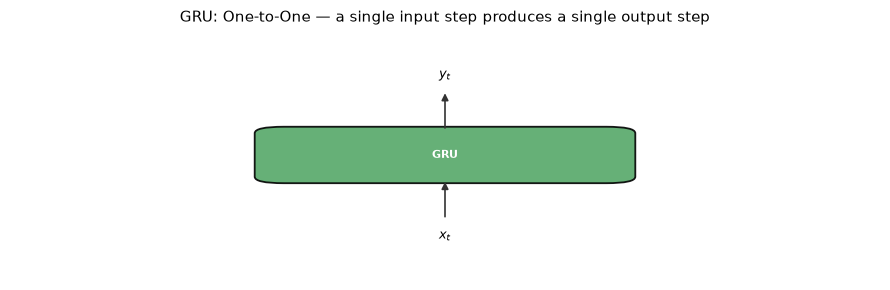

In [7]:
draw_rnn_typology(
    pattern=[(True, True)],
    title="GRU: One-to-One — a single input step produces a single output step",
    cell_label="GRU",
)

In [8]:
X1, y1 = make_one_to_one(train_scaled)
Xv1, yv1 = make_one_to_one(val_scaled)
print("X shape:", X1.shape, " y shape:", y1.shape)

model_one_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    # --- Stack an additional GRU layer: ------------------------------
    # 1) change `return_sequences=False` above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.GRU(UNITS, return_sequences=False),
    # -------------------------------------------------------------------------------
    tf.keras.layers.Dense(1),
], name="gru_one_to_one")

model_one_to_one.summary()
show_model_diagram(model_one_to_one, "gru_one_to_one.png")

X shape: (2099, 1, 5)  y shape: (2099, 1)


Model: "gru_one_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_one: ran 100/100 epochs  final val_loss=0.00862  val_mae=0.07342  params=3,777


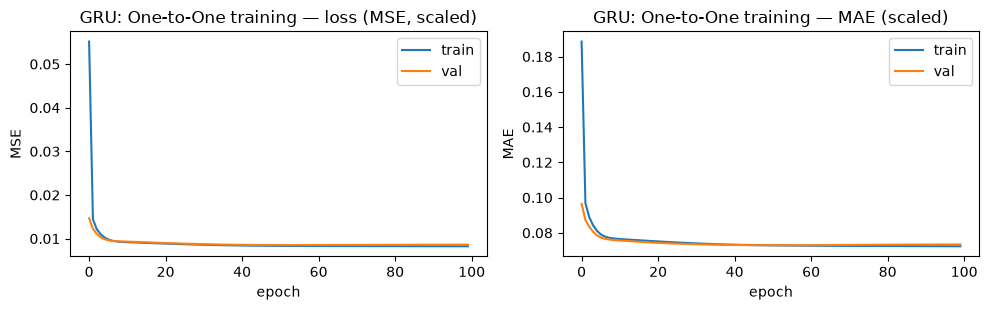

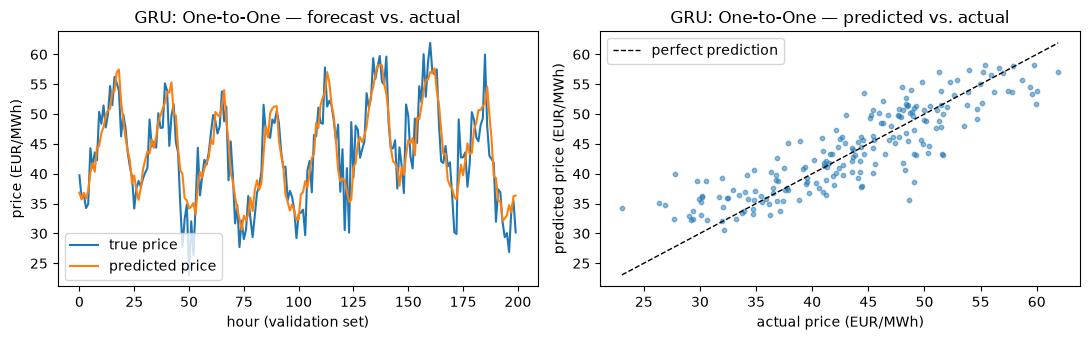

In [9]:
hist_1to1 = compile_and_fit(model_one_to_one, "one_to_one", X1, y1, Xv1, yv1)
plot_history(hist_1to1, "GRU: One-to-One training")

pred = model_one_to_one.predict(Xv1, verbose=0)
plot_point_prediction(yv1, pred, "GRU: One-to-One")

In [24]:
# One-to-One – 2-Layer GRU

model_one_to_one_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="gru_one_to_one_2layer")

model_one_to_one_2layer.summary()

Model: "gru_one_to_one_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_7 (GRU)                     │ (None, 1, 32)          │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train One-to-One – 2-Layer GRU

hist_1to1_2layer = compile_and_fit(
    model_one_to_one_2layer,
    "one_to_one_2layer",
    X1,
    y1,
    Xv1,
    yv1
)

one_to_one_2layer: ran 100/100 epochs  final val_loss=0.00870  val_mae=0.07431  params=10,113


In [28]:
# Metrics – One-to-One 2-Layer GRU

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_1to1_2layer = model_one_to_one_2layer.predict(Xv1, verbose=0)

mae_1to1_2layer = mean_absolute_error(yv1.flatten(), pred_1to1_2layer.flatten())
mse_1to1_2layer = mean_squared_error(yv1.flatten(), pred_1to1_2layer.flatten())
rmse_1to1_2layer = np.sqrt(mse_1to1_2layer)
r2_1to1_2layer = r2_score(yv1.flatten(), pred_1to1_2layer.flatten())

print(f"MAE  : {mae_1to1_2layer:.6f}")
print(f"MSE  : {mse_1to1_2layer:.6f}")
print(f"RMSE : {rmse_1to1_2layer:.6f}")
print(f"R²   : {r2_1to1_2layer:.6f}")

MAE  : 0.074314
MSE  : 0.008705
RMSE : 0.093299
R²   : 0.720504


## 6. Architecture Type B — Many-to-One

`return_sequences=False` (the Keras default): the GRU layer consumes
the full `WINDOW`-hour window and only its **final** hidden state is passed to the
Dense output layer. This is the classic setup for "predict the next value from
recent history" — e.g. tomorrow's price from the last 24 hours of load/generation/price.

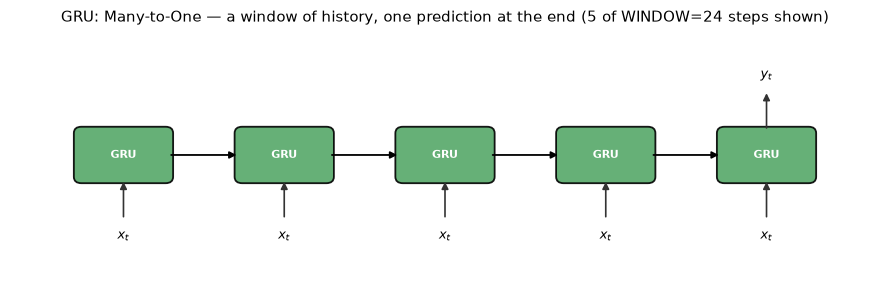

In [10]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(True, True)],
    title=f"GRU: Many-to-One — a window of history, one prediction at the end (5 of WINDOW={WINDOW} steps shown)",
    cell_label="GRU",
)

In [11]:
Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

model_many_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    # --- Stack an additional GRU layer: ------------------------------
    # 1) change `return_sequences=False` above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.GRU(UNITS, return_sequences=False),
    # -------------------------------------------------------------------------------
    tf.keras.layers.Dense(1),
], name="gru_many_to_one")

model_many_to_one.summary()
show_model_diagram(model_many_to_one, "gru_many_to_one.png")

X shape: (2076, 24, 5)  y shape: (2076, 1)


Model: "gru_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_one: ran 100/100 epochs  final val_loss=0.00815  val_mae=0.07248  params=3,777


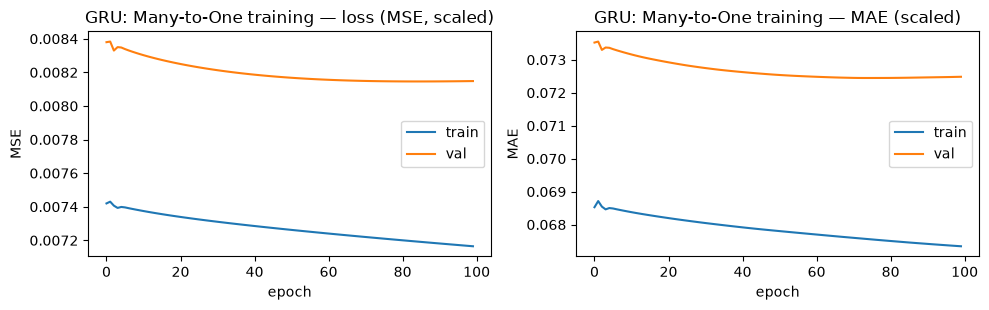

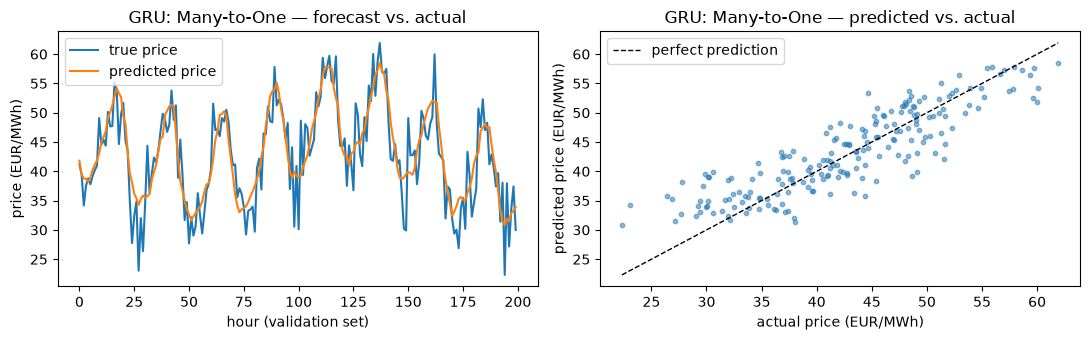

In [29]:
hist_m21 = compile_and_fit(model_many_to_one, "many_to_one", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_m21, "GRU: Many-to-One training")

pred = model_many_to_one.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "GRU: Many-to-One")

In [30]:
# Many-to-One – 2-Layer GRU

model_many_to_one_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="gru_many_to_one_2layer")

model_many_to_one_2layer.summary()

Model: "gru_many_to_one_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_9 (GRU)                     │ (None, 24, 32)         │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train Many-to-One – 2-Layer GRU

hist_m2o_2layer = compile_and_fit(
    model_many_to_one_2layer,
    "many_to_one_2layer",
    Xm1,
    ym1,
    Xv_m1,
    yv_m1
)

many_to_one_2layer: ran 100/100 epochs  final val_loss=0.00827  val_mae=0.07317  params=10,113


In [33]:
# Metrics – Many-to-One 2-Layer GRU

pred_m2o_2layer = model_many_to_one_2layer.predict(Xv_m1, verbose=0)

mae_m2o_2layer = mean_absolute_error(yv_m1.flatten(), pred_m2o_2layer.flatten())
mse_m2o_2layer = mean_squared_error(yv_m1.flatten(), pred_m2o_2layer.flatten())
rmse_m2o_2layer = np.sqrt(mse_m2o_2layer)
r2_m2o_2layer = r2_score(yv_m1.flatten(), pred_m2o_2layer.flatten())

print(f"MAE  : {mae_m2o_2layer:.6f}")
print(f"MSE  : {mse_m2o_2layer:.6f}")
print(f"RMSE : {rmse_m2o_2layer:.6f}")
print(f"R²   : {r2_m2o_2layer:.6f}")

MAE  : 0.073167
MSE  : 0.008266
RMSE : 0.090918
R²   : 0.737439


## 7. Architecture Type C — One-to-Many

A single timestep is encoded into a hidden state, `RepeatVector(OUT_LEN)` copies that
state to seed every step of a *second* GRU layer (`return_sequences=True`),
and `TimeDistributed(Dense(1))` applies the same output projection independently at
every generated step. This turns one snapshot into a generated sequence — e.g. one
hour's conditions kicking off a `{OUT_LEN}`-hour price forecast run, or (more classically)
one image feature vector generating a caption word-by-word.

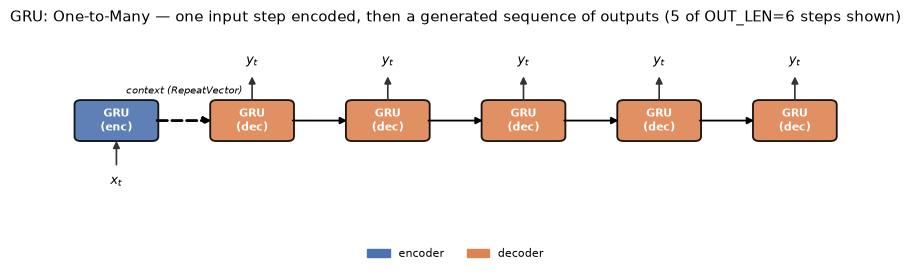

In [13]:
draw_rnn_typology(
    pattern=[(True, False)] + [(False, True)] * 5,
    title=f"GRU: One-to-Many — one input step encoded, then a generated sequence of outputs (5 of OUT_LEN={OUT_LEN} steps shown)",
    cell_label="GRU",
    encoder_decoder=True,
    split=1,
    context_label="context (RepeatVector)",
)

In [14]:
Xo, yo = make_one_to_many(train_scaled, out_len=OUT_LEN)
Xv_o, yv_o = make_one_to_many(val_scaled, out_len=OUT_LEN)
print("X shape:", Xo.shape, " y shape:", yo.shape)

model_one_to_many = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),   # encoder
    # --- Stack an additional encoder layer: ----------------------------------------
    # 1) change `return_sequences=False` on the encoder line above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.GRU(UNITS, return_sequences=False),  # 2nd encoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.GRU(UNITS, return_sequences=True),    # decoder
    # --- Stack an additional decoder layer (safe to uncomment directly, ------------
    #     since return_sequences is already True on the decoder line above): -------
    # tf.keras.layers.GRU(UNITS, return_sequences=True),   # 2nd decoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="gru_one_to_many")

model_one_to_many.summary()
show_model_diagram(model_one_to_many, "gru_one_to_many.png")

X shape: (2093, 1, 5)  y shape: (2093, 6, 1)


Model: "gru_one_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 6, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_many: ran 100/100 epochs  final val_loss=0.01044  val_mae=0.08082  params=10,113


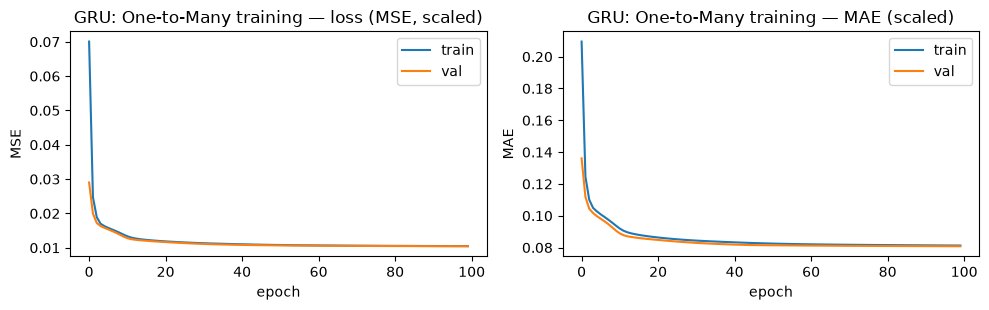

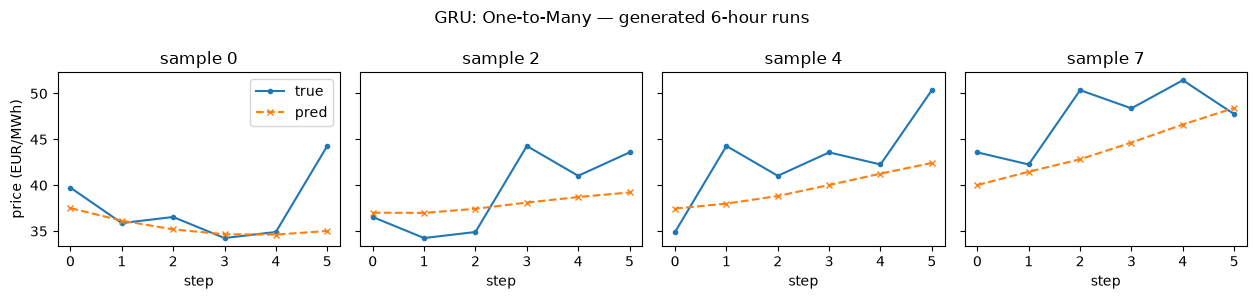

In [15]:
hist_1tm = compile_and_fit(model_one_to_many, "one_to_many", Xo, yo, Xv_o, yv_o)
plot_history(hist_1tm, "GRU: One-to-Many training")

pred = model_one_to_many.predict(Xv_o[:8], verbose=0)
plot_sequence_prediction(yv_o[:8], pred, f"GRU: One-to-Many — generated {OUT_LEN}-hour runs")

In [34]:
# One-to-Many – 2-Layer GRU

model_one_to_many_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
], name="gru_one_to_many_2layer")

model_one_to_many_2layer.summary()

Model: "gru_one_to_many_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ (None, 6, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train One-to-Many – 2-Layer GRU

hist_1tom_2layer = compile_and_fit(
    model_one_to_many_2layer,
    "one_to_many_2layer",
    Xo,
    yo,
    Xv_o,
    yv_o
)

one_to_many_2layer: ran 100/100 epochs  final val_loss=0.01063  val_mae=0.08125  params=10,113


In [37]:
# Metrics – One-to-Many 2-Layer GRU

pred_1tom_2layer = model_one_to_many_2layer.predict(Xv_o, verbose=0)

mae_1tom_2layer = mean_absolute_error(yv_o.flatten(), pred_1tom_2layer.flatten())
mse_1tom_2layer = mean_squared_error(yv_o.flatten(), pred_1tom_2layer.flatten())
rmse_1tom_2layer = np.sqrt(mse_1tom_2layer)
r2_1tom_2layer = r2_score(yv_o.flatten(), pred_1tom_2layer.flatten())

print(f"MAE  : {mae_1tom_2layer:.6f}")
print(f"MSE  : {mse_1tom_2layer:.6f}")
print(f"RMSE : {rmse_1tom_2layer:.6f}")
print(f"R²   : {r2_1tom_2layer:.6f}")

MAE  : 0.081247
MSE  : 0.010632
RMSE : 0.103114
R²   : 0.658186


## 8. Architecture Type D — Many-to-Many (Synced)

`return_sequences=True` on a *single* GRU layer, wrapped by
`TimeDistributed(Dense(1))`: the network emits one prediction **per input timestep**,
aligned in lockstep with the input (output length == input length). This is the shape
used for per-timestep sequence labeling tasks (POS tagging, per-frame classification)
— here, predicting the next hour's price at every position of a sliding window,
rather than only at the end as Many-to-One does.

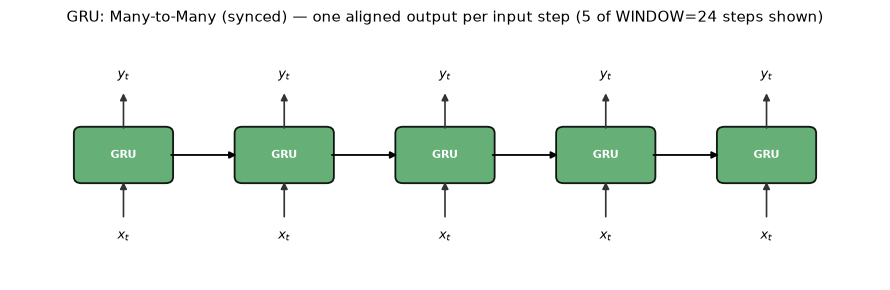

In [16]:
draw_rnn_typology(
    pattern=[(True, True)] * 5,
    title=f"GRU: Many-to-Many (synced) — one aligned output per input step (5 of WINDOW={WINDOW} steps shown)",
    cell_label="GRU",
)

In [17]:
Xs, ys = make_synced_many_to_many(train_scaled, window=WINDOW)
Xv_s, yv_s = make_synced_many_to_many(val_scaled, window=WINDOW)
print("X shape:", Xs.shape, " y shape:", ys.shape)

model_synced = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    # --- Stack an additional GRU layer (safe to uncomment directly, ---
    #     since return_sequences is already True above): ---------------------------
    # tf.keras.layers.GRU(UNITS, return_sequences=True),
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="gru_synced_many_to_many")

model_synced.summary()
show_model_diagram(model_synced, "gru_synced_many_to_many.png")

X shape: (2075, 24, 5)  y shape: (2075, 24, 1)


Model: "gru_synced_many_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 24, 32)         │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_synced: ran 100/100 epochs  final val_loss=0.00863  val_mae=0.07382  params=3,777


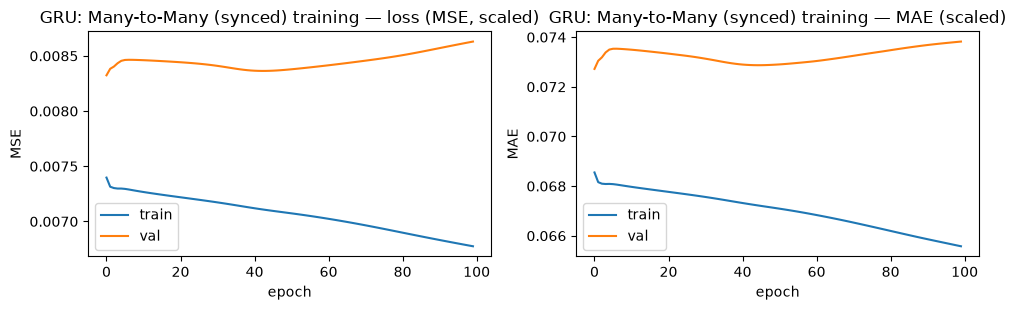

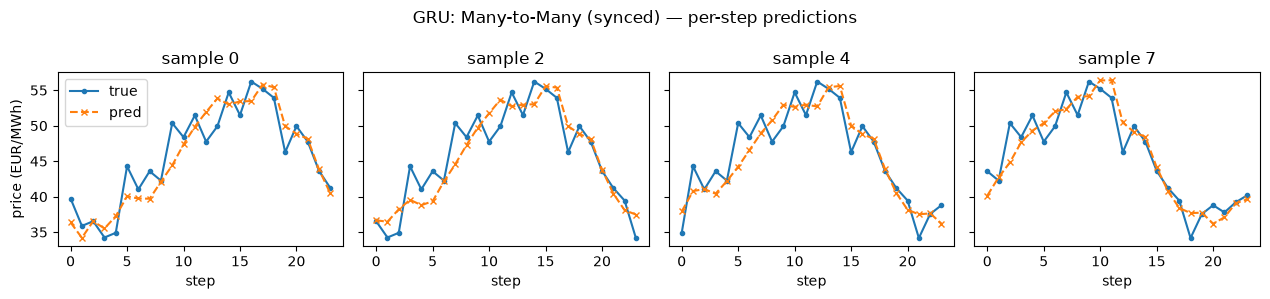

In [38]:
hist_sync = compile_and_fit(model_synced, "many_to_many_synced", Xs, ys, Xv_s, yv_s)
plot_history(hist_sync, "GRU: Many-to-Many (synced) training")

pred = model_synced.predict(Xv_s[:8], verbose=0)
plot_sequence_prediction(yv_s[:8], pred, "GRU: Many-to-Many (synced) — per-step predictions")

In [39]:
# Many-to-Many (Synced) – 2-Layer GRU

model_synced_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
], name="gru_synced_many_to_many_2layer")

model_synced_2layer.summary()

Model: "gru_synced_many_to_many_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_13 (GRU)                    │ (None, 24, 32)         │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_14 (GRU)                    │ (None, 24, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train Many-to-Many (Synced) – 2-Layer GRU

hist_sync_2layer = compile_and_fit(
    model_synced_2layer,
    "many_to_many_synced_2layer",
    Xs,
    ys,
    Xv_s,
    yv_s
)

many_to_many_synced_2layer: ran 100/100 epochs  final val_loss=0.00845  val_mae=0.07356  params=10,113


In [41]:
# Metrics – Many-to-Many (Synced) 2-Layer GRU

pred_sync_2layer = model_synced_2layer.predict(Xv_s, verbose=0)

mae_sync_2layer = mean_absolute_error(yv_s.flatten(), pred_sync_2layer.flatten())
mse_sync_2layer = mean_squared_error(yv_s.flatten(), pred_sync_2layer.flatten())
rmse_sync_2layer = np.sqrt(mse_sync_2layer)
r2_sync_2layer = r2_score(yv_s.flatten(), pred_sync_2layer.flatten())

print(f"MAE  : {mae_sync_2layer:.6f}")
print(f"MSE  : {mse_sync_2layer:.6f}")
print(f"RMSE : {rmse_sync_2layer:.6f}")
print(f"R²   : {r2_sync_2layer:.6f}")

MAE  : 0.073557
MSE  : 0.008449
RMSE : 0.091921
R²   : 0.731743


## 9. Architecture Type E — Many-to-Many (Encoder–Decoder / Seq2Seq)

The general many-to-many case, where input length and output length can differ
(`IN_WINDOW={WINDOW}` hours in, `OUT_HORIZON={OUT_LEN}` hours out). An **encoder**
GRU compresses the input window into a single context vector
(`return_sequences=False`); `RepeatVector` seeds a **decoder** GRU
(`return_sequences=True`); `TimeDistributed(Dense(1))` projects each decoder step to
a prediction. This is the same encoder-decoder pattern used for machine translation
and multi-step time-series forecasting — the "sequence in, differently-sized
sequence out" case that Many-to-One and the synced Many-to-Many above can't express.

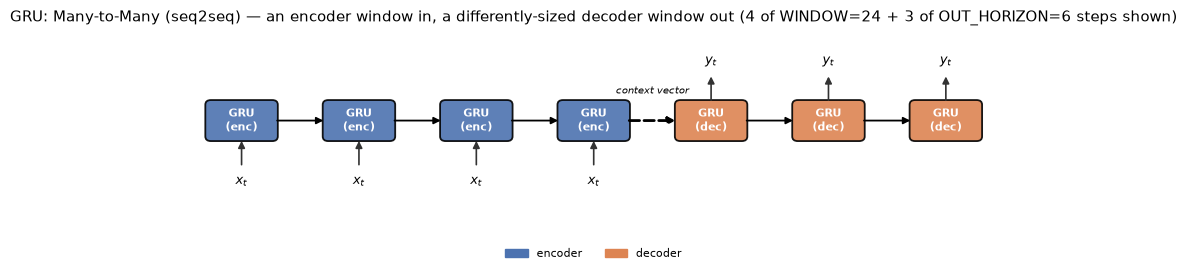

In [19]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(False, True)] * 3,
    title=f"GRU: Many-to-Many (seq2seq) — an encoder window in, a differently-sized decoder window out (4 of WINDOW={WINDOW} + 3 of OUT_HORIZON={OUT_LEN} steps shown)",
    cell_label="GRU",
    encoder_decoder=True,
    split=4,
    context_label="context vector",
)

In [20]:
Xe, ye = make_seq2seq(train_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
Xv_e, yv_e = make_seq2seq(val_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
print("X shape:", Xe.shape, " y shape:", ye.shape)

model_seq2seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),   # encoder
    # --- Stack an additional encoder layer: ----------------------------------------
    # 1) change `return_sequences=False` on the encoder line above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.GRU(UNITS, return_sequences=False),  # 2nd encoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.GRU(UNITS, return_sequences=True),    # decoder
    # --- Stack an additional decoder layer (safe to uncomment directly, ------------
    #     since return_sequences is already True on the decoder line above): -------
    # tf.keras.layers.GRU(UNITS, return_sequences=True),   # 2nd decoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="gru_seq2seq")

model_seq2seq.summary()
show_model_diagram(model_seq2seq, "gru_seq2seq.png")

X shape: (2070, 24, 5)  y shape: (2070, 6, 1)


Model: "gru_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 6, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_seq2seq: ran 100/100 epochs  final val_loss=0.00799  val_mae=0.07170  params=10,113


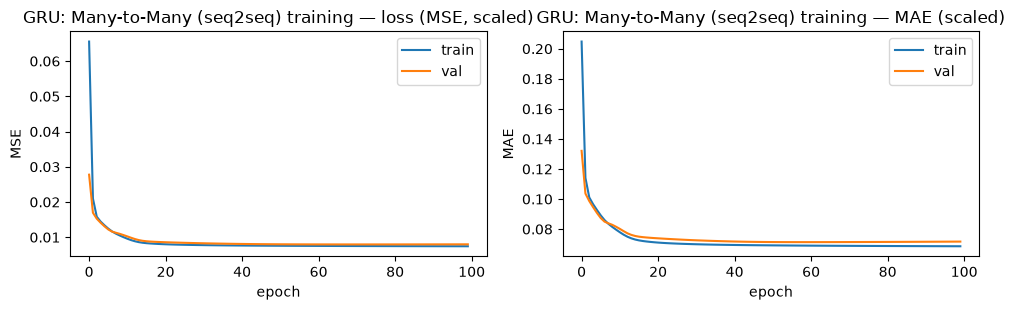

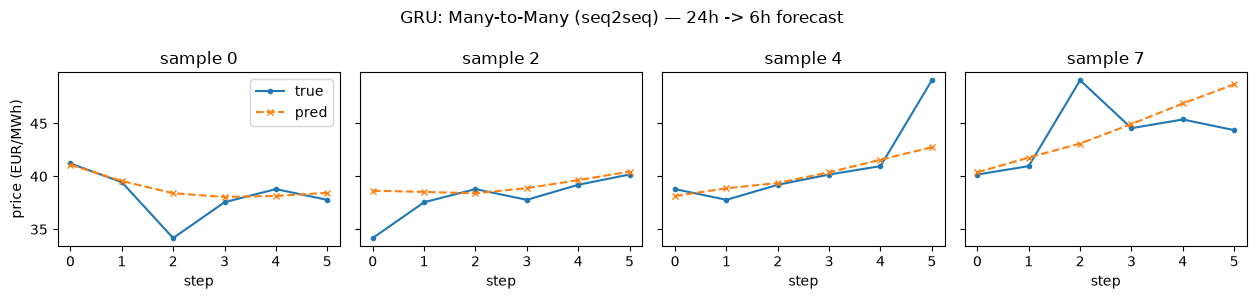

In [21]:
hist_s2s = compile_and_fit(model_seq2seq, "many_to_many_seq2seq", Xe, ye, Xv_e, yv_e)
plot_history(hist_s2s, "GRU: Many-to-Many (seq2seq) training")

pred = model_seq2seq.predict(Xv_e[:8], verbose=0)
plot_sequence_prediction(yv_e[:8], pred, f"GRU: Many-to-Many (seq2seq) — {WINDOW}h -> {OUT_LEN}h forecast")

In [42]:
# Many-to-Many (Seq2Seq) – 2-Layer GRU

model_seq2seq_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.GRU(UNITS, return_sequences=False),
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.GRU(UNITS, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
], name="gru_seq2seq_2layer")

model_seq2seq_2layer.summary()

Model: "gru_seq2seq_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_15 (GRU)                    │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_16 (GRU)                    │ (None, 6, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

many_to_many_seq2seq_2layer: ran 100/100 epochs  final val_loss=0.00791  val_mae=0.07115  params=10,113


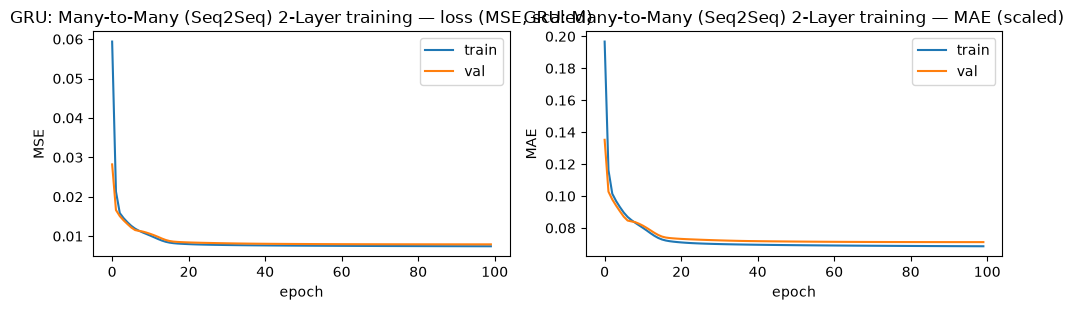

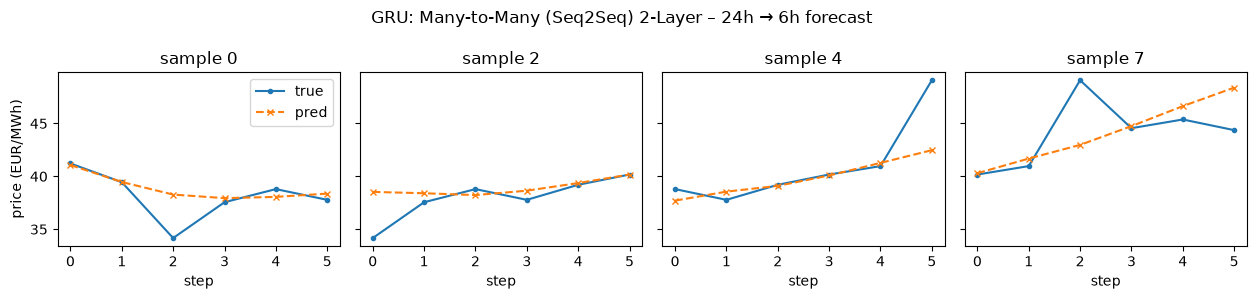

In [43]:
# Train Many-to-Many (Seq2Seq) – 2-Layer GRU

hist_s2s_2layer = compile_and_fit(
    model_seq2seq_2layer,
    "many_to_many_seq2seq_2layer",
    Xe,
    ye,
    Xv_e,
    yv_e
)

plot_history(
    hist_s2s_2layer,
    "GRU: Many-to-Many (Seq2Seq) 2-Layer training"
)

pred = model_seq2seq_2layer.predict(Xv_e[:8], verbose=0)

plot_sequence_prediction(
    yv_e[:8],
    pred,
    f"GRU: Many-to-Many (Seq2Seq) 2-Layer – {WINDOW}h → {OUT_LEN}h forecast"
)

In [44]:
# Metrics – Many-to-Many (Seq2Seq) 2-Layer GRU

pred_s2s_2layer = model_seq2seq_2layer.predict(Xv_e, verbose=0)

mae_s2s_2layer = mean_absolute_error(
    yv_e.flatten(), pred_s2s_2layer.flatten()
)

mse_s2s_2layer = mean_squared_error(
    yv_e.flatten(), pred_s2s_2layer.flatten()
)

rmse_s2s_2layer = np.sqrt(mse_s2s_2layer)

r2_s2s_2layer = r2_score(
    yv_e.flatten(), pred_s2s_2layer.flatten()
)

print(f"MAE  : {mae_s2s_2layer:.6f}")
print(f"MSE  : {mse_s2s_2layer:.6f}")
print(f"RMSE : {rmse_s2s_2layer:.6f}")
print(f"R²   : {r2_s2s_2layer:.6f}")

MAE  : 0.071149
MSE  : 0.007913
RMSE : 0.088954
R²   : 0.748721


In [46]:
# Advanced Challenge – CNN + GRU
# Many-to-Many (Seq2Seq)

model_cnn_gru_seq2seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    
    # CNN layer: 32 filters, kernel size = 3
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    
    # GRU encoder
    tf.keras.layers.GRU(
        UNITS,
        return_sequences=False
    ),
    
    # Repeat for 6 output steps
    tf.keras.layers.RepeatVector(OUT_LEN),
    
    # GRU decoder
    tf.keras.layers.GRU(
        UNITS,
        return_sequences=True
    ),
    
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1)
    )
], name="cnn_gru_seq2seq")

model_cnn_gru_seq2seq.summary()

Model: "cnn_gru_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_17 (GRU)                    │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_18 (GRU)                    │ (None, 6, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

cnn_gru_seq2seq: ran 100/100 epochs  final val_loss=0.00803  val_mae=0.07138  params=13,217


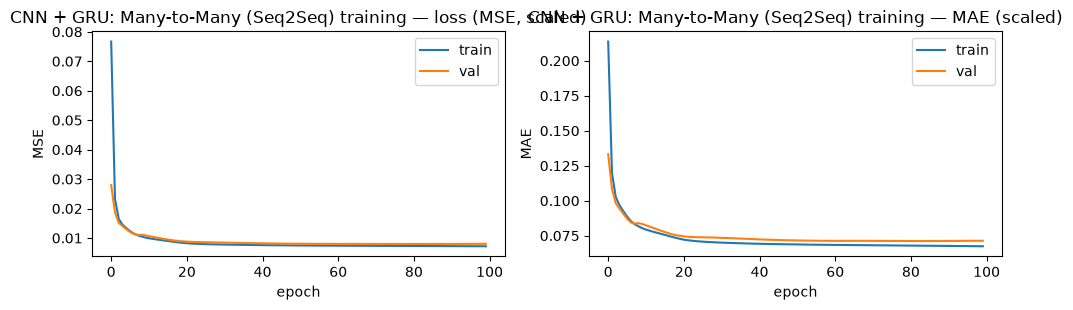

In [47]:
# Train Advanced Challenge – CNN + GRU

hist_cnn_gru = compile_and_fit(
    model_cnn_gru_seq2seq,
    "cnn_gru_seq2seq",
    Xe,
    ye,
    Xv_e,
    yv_e# Metrics – CNN + GRU Advanced Challenge

pred_cnn_gru = model_cnn_gru_seq2seq.predict(Xv_e, verbose=0)

mae_cnn_gru = mean_absolute_error(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

mse_cnn_gru = mean_squared_error(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

rmse_cnn_gru = np.sqrt(mse_cnn_gru)

r2_cnn_gru = r2_score(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

print(f"MAE  : {mae_cnn_gru:.6f}")
print(f"MSE  : {mse_cnn_gru:.6f}")
print(f"RMSE : {rmse_cnn_gru:.6f}")
print(f"R²   : {r2_cnn_gru:.6f}")
)

plot_history(
    hist_cnn_gru,
    "CNN + GRU: Many-to-Many (Seq2Seq) training"
)

In [48]:
# Metrics – CNN + GRU Advanced Challenge

pred_cnn_gru = model_cnn_gru_seq2seq.predict(Xv_e, verbose=0)

mae_cnn_gru = mean_absolute_error(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

mse_cnn_gru = mean_squared_error(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

rmse_cnn_gru = np.sqrt(mse_cnn_gru)

r2_cnn_gru = r2_score(
    yv_e.flatten(), pred_cnn_gru.flatten()
)

print(f"MAE  : {mae_cnn_gru:.6f}")
print(f"MSE  : {mse_cnn_gru:.6f}")
print(f"RMSE : {rmse_cnn_gru:.6f}")
print(f"R²   : {r2_cnn_gru:.6f}")

MAE  : 0.071382
MSE  : 0.008033
RMSE : 0.089627
R²   : 0.744904


In [45]:
# ============================================================
# BEST GRU TYPOLOGY AFTER ADDING ANOTHER GRU LAYER
# ============================================================
#
# After adding a second GRU layer, the five typologies were
# evaluated using MAE, MSE, RMSE, and R².
#
# Lower MAE, MSE, and RMSE indicate better performance,
# while a higher R² indicates better performance.
#
# Results:
#
# Typology                         MAE       MSE       RMSE      R²
# One-to-One – 2-Layer             0.074314  0.008705  0.093299  0.720504
# Many-to-One – 2-Layer            0.073167  0.008266  0.090918  0.737439
# One-to-Many – 2-Layer            0.081247  0.010632  0.103114  0.658186
# Many-to-Many (Synced) – 2-Layer  0.073557  0.008449  0.091921  0.731743
# Many-to-Many (Seq2Seq) – 2-Layer 0.071149  0.007913  0.088954  0.748721
#
# The Many-to-Many (Seq2Seq) 2-Layer GRU performed best.
# It achieved the lowest MAE, MSE, and RMSE, and the highest
# R² score of 0.748721.
#
# Therefore, adding another GRU layer resulted in the best
# performance for the Many-to-Many (Seq2Seq) typology.
# ============================================================

In [ ]:
# ============================================================
# CONCLUSION – ADVANCED CHALLENGE (ITEM 4)
# ============================================================
#
# The CNN + GRU model used one CNN layer with 32 filters and
# a kernel size of 3, followed by the GRU layers, and was
# trained for 100 epochs.
#
# Performance:
# MAE  = 0.071382
# MSE  = 0.008033
# RMSE = 0.089627
# R²   = 0.744904
#
# The results show that the CNN + GRU model achieved good
# predictive performance, with relatively low prediction
# errors and an R² of 0.744904.
#
# Therefore, the CNN + GRU model was effective for the
# Many-to-Many (Seq2Seq) energy forecasting task.
# ============================================================

In [49]:
# ============================================================
# COMPARISON – ITEM 4 vs ONE-LAYER RNN
# ============================================================
#
# Item 4 CNN + GRU (Many-to-Many Seq2Seq):
# MAE  = 0.071382
# MSE  = 0.008033
# RMSE = 0.089627
# R²   = 0.744904
#
# One-Layer RNN (Many-to-Many Seq2Seq):
# MAE  = 0.073580
# MSE  = 0.008417
# RMSE = 0.091747
# R²   = 0.732698
#
# The CNN + GRU model performed better than the one-layer RNN.
# It achieved lower MAE, MSE, and RMSE, and a higher R² score.
#
# This indicates that adding a CNN layer before the GRU helped
# extract local patterns from the input sequence, improving
# the forecasting performance.
#
# Note: The CNN + GRU model was evaluated only on the
# Many-to-Many (Seq2Seq) typology, so a direct comparison with
# the one-layer RNN is made using the same typology.
# ============================================================

## 10. Summary & Comparison

Recap of the five typologies built above, all using the same **GRU** cell:

| Type | Input shape | Output shape | `return_sequences` pattern | Example use here |
|---|---|---|---|---|
| One-to-one | `(1, features)` | `(1,)` | n/a (single step) | next-hour price from this hour only |
| Many-to-one | `(window, features)` | `(1,)` | `False` | next-hour price from last 24h |
| One-to-many | `(1, features)` | `(out_len, 1)` | encoder `False`, decoder `True` | generate a {OUT_LEN}-hour forecast from one snapshot |
| Many-to-many (synced) | `(window, features)` | `(window, 1)` | `True` | per-step next-value prediction |
| Many-to-many (seq2seq) | `(in_window, features)` | `(out_horizon, 1)` | encoder `False`, decoder `True` | {WINDOW}h history -> {OUT_LEN}h forecast |

The cell below tabulates trained parameter counts and final validation loss/MAE for
every architecture in this notebook, so you can see how model size scales with the
task shape even though the underlying GRU cell is identical throughout.

In [50]:
rows = []
for name, model in [
    ("one_to_one", model_one_to_one),
    ("many_to_one", model_many_to_one),
    ("one_to_many", model_one_to_many),
    ("many_to_many_synced", model_synced),
    ("many_to_many_seq2seq", model_seq2seq),
]:
    h = history_log[name]
    rows.append({
        "architecture": name,
        "params": model.count_params(),
        "final_val_loss_mse": h.history["val_loss"][-1],
        "final_val_mae": h.history["val_mae"][-1],
    })

summary_df = pd.DataFrame(rows).set_index("architecture")
summary_df

,params,final_val_loss_mse,final_val_mae
architecture,,,
one_to_one,3777,0.008617,0.073422
many_to_one,3777,0.008148,0.072484
one_to_many,10113,0.010441,0.080817
many_to_many_synced,3777,0.008630,0.073822
many_to_many_seq2seq,10113,0.007987,0.071698


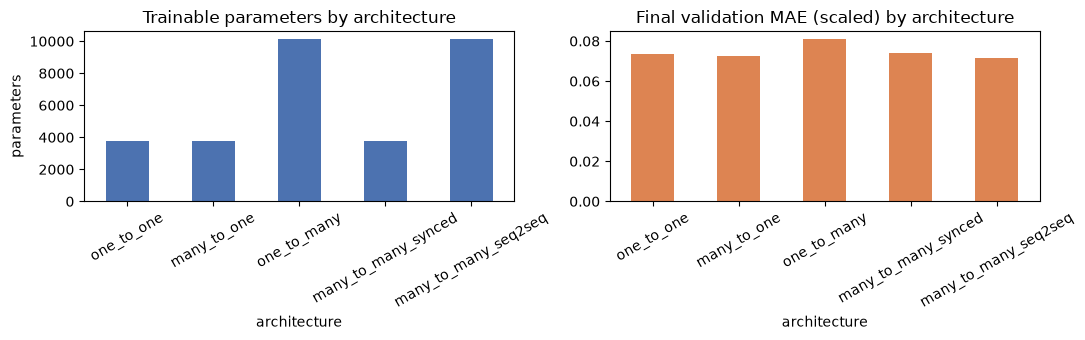

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
summary_df["params"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Trainable parameters by architecture")
axes[0].set_ylabel("parameters")
axes[0].tick_params(axis="x", rotation=30)

summary_df["final_val_mae"].plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Final validation MAE (scaled) by architecture")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## References & Notes

- Dataset: Nicholas J. Hana, *Hourly Energy Demand Generation and Weather*, Kaggle
  (`nicholasjhana/energy-consumption-generation-prices-and-weather`).
- Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*, Neural Computation 9(8).
- Cho et al. (2014), *Learning Phrase Representations using RNN Encoder-Decoder for
  Statistical Machine Translation* (introduces the GRU).
- Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks* — the
  original source of the one-to-one / one-to-many / many-to-one / many-to-many
  diagram this notebook implements in code.

**GRU has no output gate and no separate cell state — compare its parameter count and training speed against the LSTM notebook on identical data/windows.**

**Companion notebooks:** the other two files in this set repeat every architecture
above with the same data pipeline, swapping only the recurrent cell
(`SimpleRNN` / `LSTM` / `GRU`) — use them side by side to compare parameter counts,
training curves, and forecast quality across cell types on identical tasks.